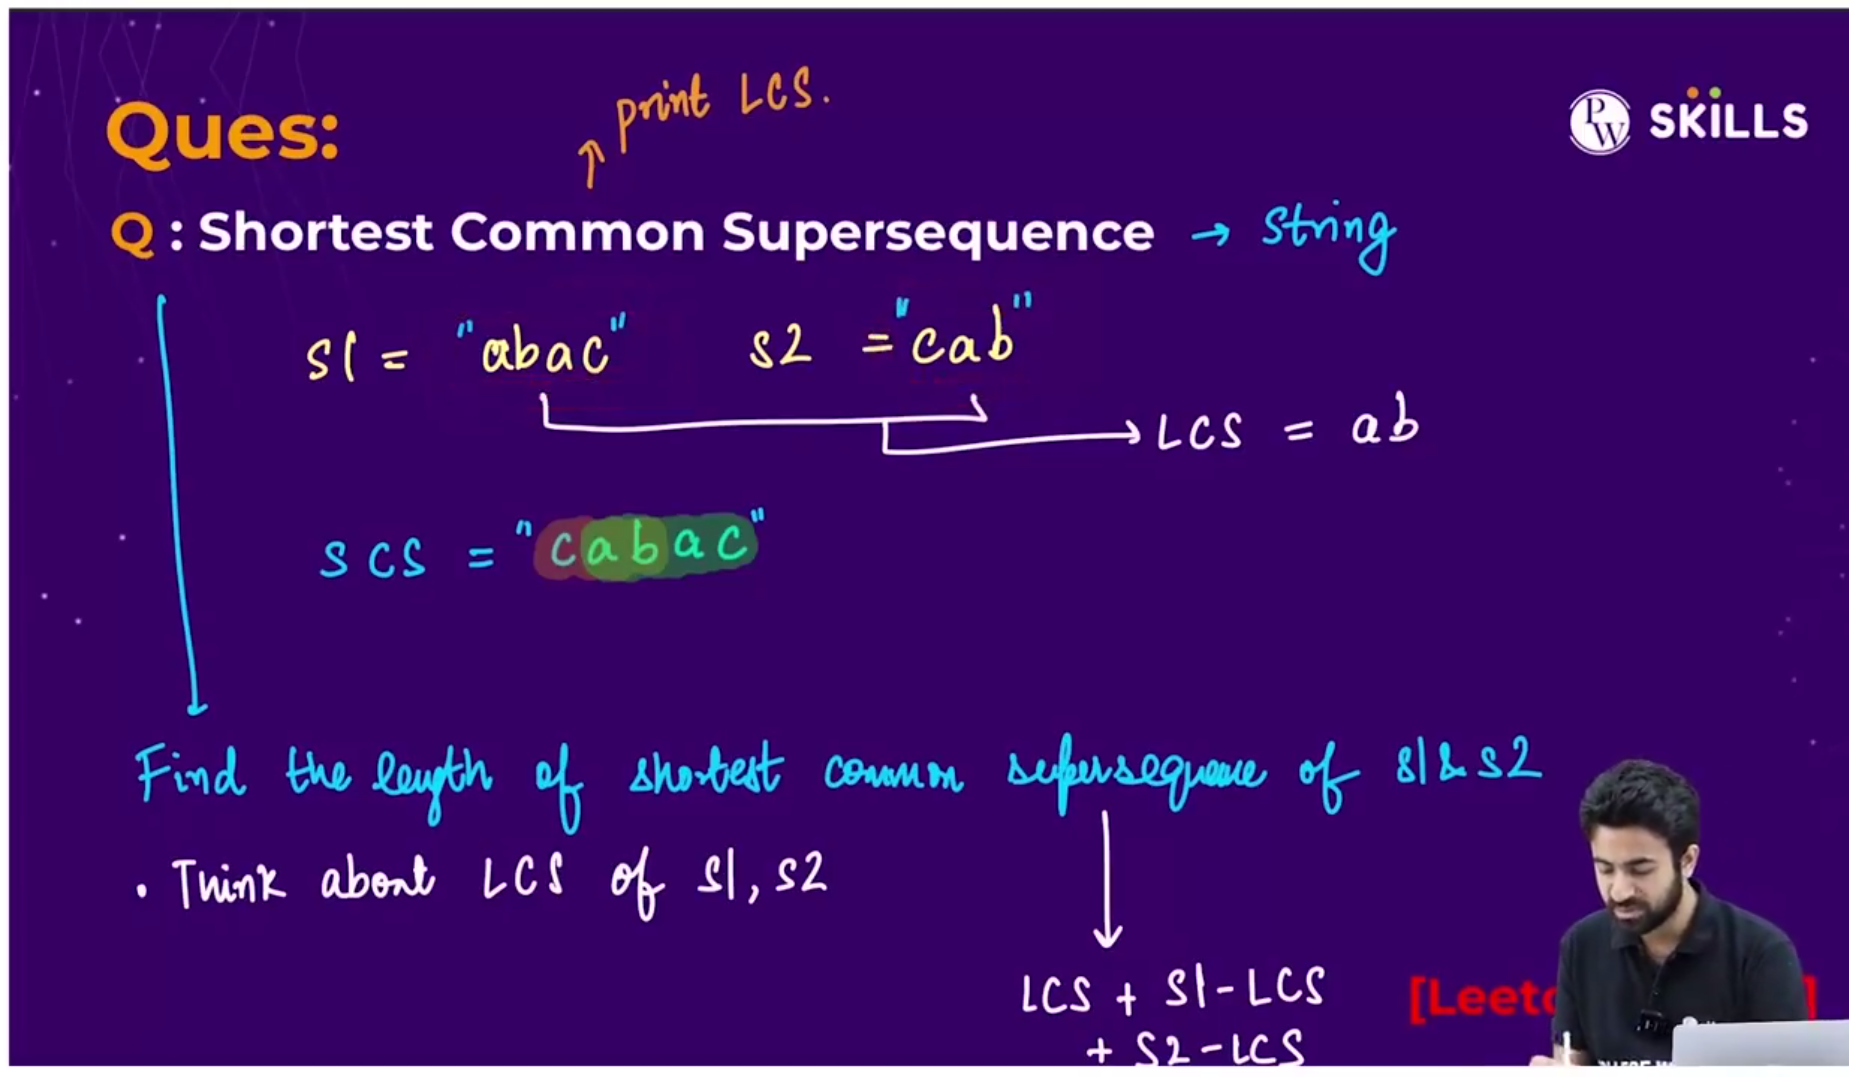

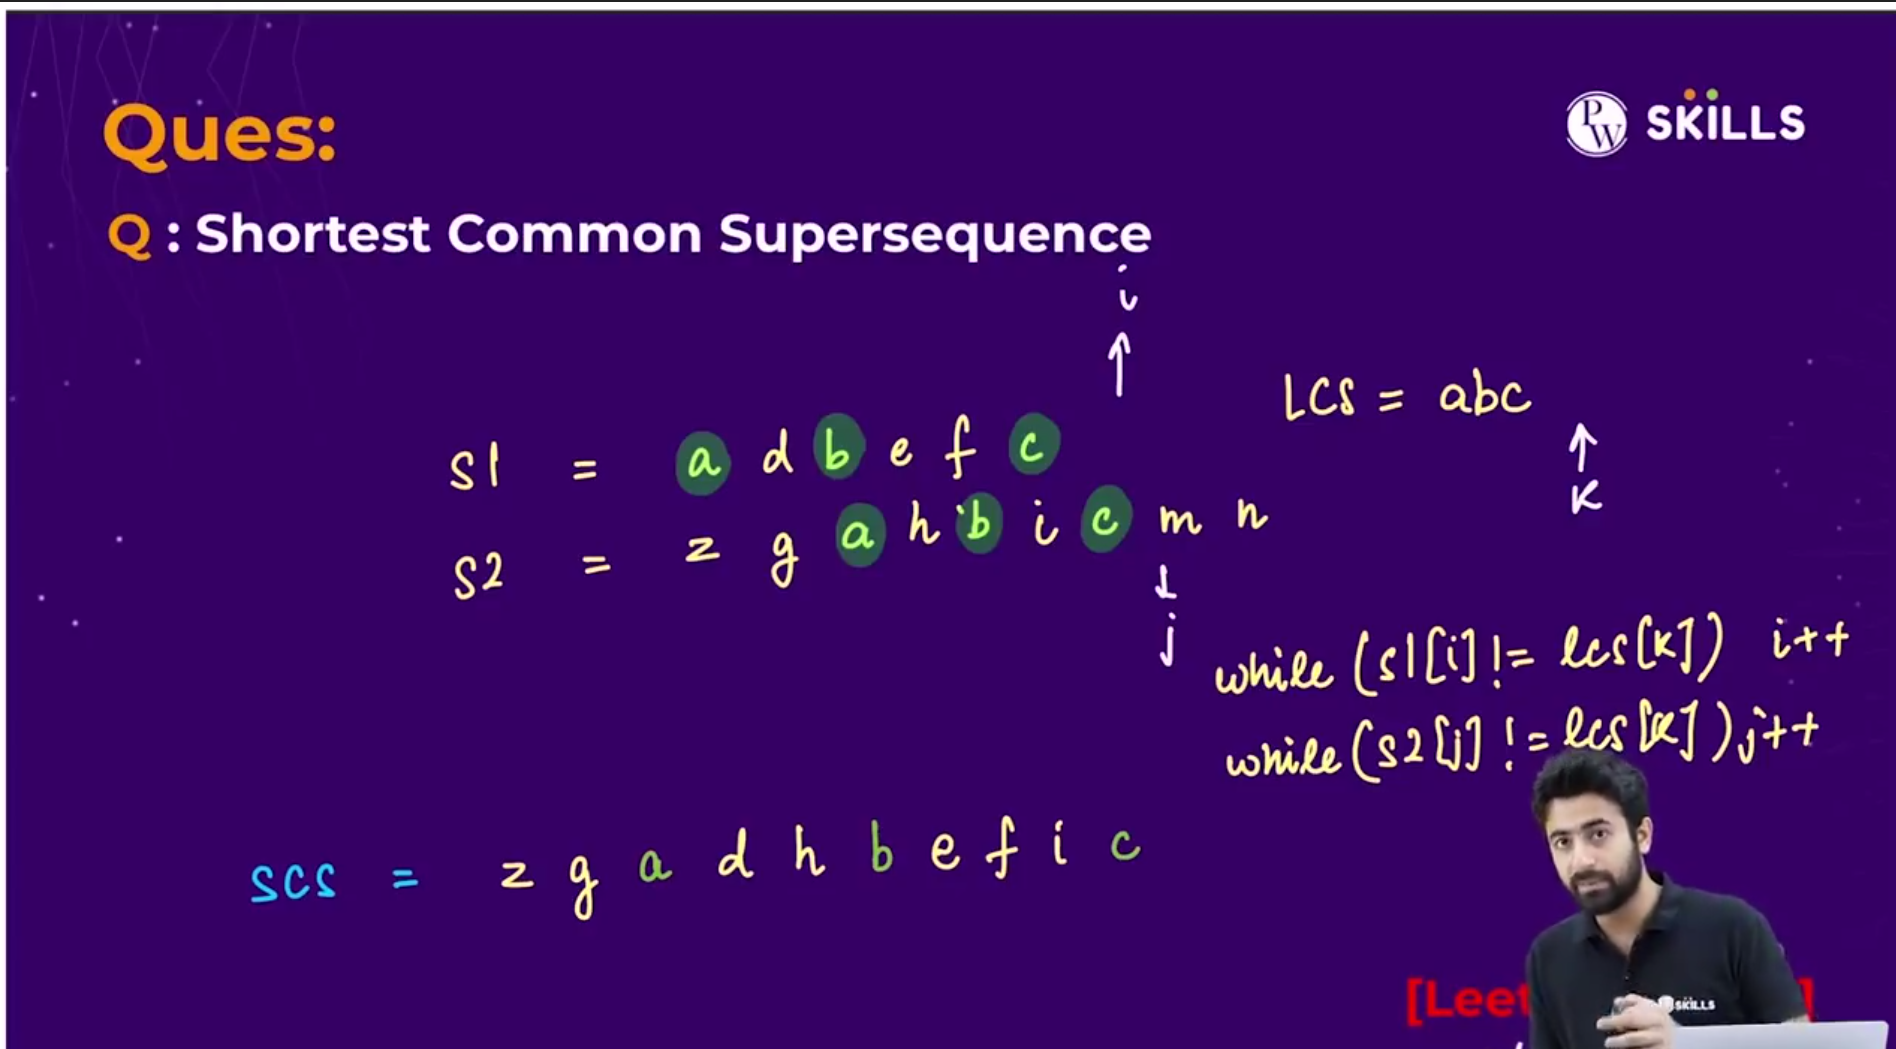

In [8]:
class Solution:
    def lcs(self, i, j, a, b, dp):
        # Base case
        if i < 0 or j < 0:
            return 0

        # Memoization
        if dp[i][j] != -1:
            return dp[i][j]

        # Characters match
        if a[i] == b[j]:
            dp[i][j] = 1 + self.lcs(i - 1, j - 1, a, b, dp)
        else:
            dp[i][j] = max(
                self.lcs(i - 1, j, a, b, dp),
                self.lcs(i, j - 1, a, b, dp)
            )

        return dp[i][j]

    def getLCS(self, a, b):
        m, n = len(a), len(b)

        dp = [[0] * (n + 1) for _ in range(m + 1)]

        # Build DP table
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if a[i - 1] == b[j - 1]:
                    dp[i][j] = 1 + dp[i - 1][j - 1]
                else:
                    dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

        # Reconstruct LCS string
        i, j = m, n
        lcs = []

        while i > 0 and j > 0:
            if a[i - 1] == b[j - 1]:
                lcs.append(a[i - 1])
                i -= 1
                j -= 1
            elif dp[i - 1][j] > dp[i][j - 1]:
                i -= 1
            else:
                j -= 1

        return "".join(reversed(lcs))

    def shortestCommonSupersequence(self, s1: str, s2: str) -> str:
        lcs = self.getLCS(s1, s2)

        i, j, k = 0, 0, 0
        scs = ""

        while i < len(s1) and j < len(s2) and k < len(lcs):
            while s1[i] != lcs[k]:
                scs += s1[i]
                i += 1

            while s2[j] != lcs[k]:
                scs += s2[j]
                j += 1

            scs += lcs[k]
            i += 1
            j += 1
            k += 1

        # Remaining characters
        while j < len(s2):
            scs += s2[j]
            j += 1

        while i < len(s1):
            scs += s1[i]
            i += 1

        return scs

In [9]:
text1 = "abcde"
text2 = "ace"
obj = Solution()
obj.shortestCommonSupersequence(text1,text2)

'abcde'